## Q2. Symmetric proposal distributions

In [346]:
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from scipy.integrate import quad

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 11

UNIFORM_COLOR = "#1f77b4"
DISCRETE_COLOR = "#d160f1"
NORMAL_COLOR = "#2ca02c"
TRUE_DENSITY_COLOR = "#ff7f0e"

In [347]:
# Fixed random generator
np.random.seed(0)
rng_proposal = np.random.default_rng(26)
rng_metropolis = np.random.default_rng(9)

## Defined functions

In [348]:
# Target function
def target_fn(x, z):
    return np.exp(-x**4)/z

# Symmetric Proposal Functions
def uniform_proposal(x, step_size=0.01, rng=rng_proposal):
    """Uniform distribution to generate new step size
    Params:
        x (float): current position of x
        step_size (float): bounds of uniform func

    Returns:
        updated_x (float): next position of x
    """
    updated_x = x + rng.uniform(-step_size, step_size)
    return updated_x

def discrete_proposal(x, step_size=0.01, rng=rng_proposal):
    """Discrete proposal to choose left and right direction and take the predefined step
    Params:
        x (float): current position of x
        step_size (float): size of each step

    Returns:
        updated_x (float): next position of x
    """
    decider = rng.uniform(0, 1)
    if decider > 0.5:
        updated_x = x + step_size
    else:
        updated_x = x - step_size
    return updated_x

def normal_proposal(x, sigma=1, rng=rng_proposal):
    """
    N(x, sigma^2) distribution to generate new step size
    Params:
        x (float): current position of x
        sigma (float): standard deviation

    Returns:
        updated_x (float): next position of x
    """
    updated_x = x + rng.normal(0, sigma)
    return updated_x

In [349]:
# Metropolis sampler with symmetric proposal function
def universal_metropolis_sampler(dist, num_samples, initial_x, z,
                                 step_size=None, sigma=None, df=None):
    """Metropolis sampler for all symmetric proposal functions
    Params:
        dist: symmetric proposal distributions (uniform, discrete, normal, student)
        num_samples (int): number of samples for simulation
        initial_x (float): initial position of x

    Returns:
        samples (np.array): arrays of generated samples
    """
    lst = {"uniform": uniform_proposal,
           "discrete": discrete_proposal,
           "normal": normal_proposal
    }

    samples = [initial_x]
    x = initial_x
    # counter for accepted proposals
    accepted = 0

    for _ in range(num_samples - 1):
        sampler = lst[dist]
        # Call the function with parameter
        if dist in ["uniform", "discrete"]:
            x_proposal = sampler(x, step_size)
        elif dist == "normal":
            x_proposal = sampler(x, sigma)
        elif dist == "student":
            x_proposal = sampler(x, df)
        else:
            raise ValueError(f"{dist} distribution is unavailable.")

        # Metropolis acceptance step
        acceptance_ratio = target_fn(x_proposal, z) / target_fn(x, z)
        if np.random.rand() < min(1, acceptance_ratio):
            x = x_proposal
            accepted += 1

        samples.append(x)

    acceptance_rate = accepted / (num_samples - 1)
    # Message
    print(f"Acceptance rate: {acceptance_rate:.4f}")

    return np.array(samples), acceptance_rate

## 2a. Estimate the normalization factor Z

In [350]:
Z = quad(lambda x: np.exp(-x**4), -np.inf, np.inf)[0]
print("Estimated normalization factor Z =", Z)

Estimated normalization factor Z = 1.8128049541109543


In [351]:
# Generate samples and number of bins
N1, N2, N3 = 50, 500, 5000
B1, B2, B3 = 30, 30, 30
INITIAL_X = 0.0
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

## 2b

To compare proposal distributions under a comparable sampling range, we used three proposals: Uniform(−1,1), discrete with step size 1, and Normal(0,0.5^2). The Normal proposal was chosen so that approximately 96% of the proposed samples fall within (−1,1), making the effective proposal ranges comparable across methods.

In [352]:
# Generate samples and number of bins
N = 1000
B1, B2, B3 = 30, 30, 30
UNIFORM_STEP = 1
DISCRETE_STEP = 1
SIGMA = 0.5
INITIAL_X = 0.0
metropolis_results = {}
# True density based on samples
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

# Metropolis samples
samples_uniform, acc_uniform = universal_metropolis_sampler(dist="uniform", num_samples=N, z=Z,
                                                            initial_x=INITIAL_X, step_size=UNIFORM_STEP)
samples_discrete, acc_discrete = universal_metropolis_sampler(dist="discrete", num_samples=N, z=Z,
                                                  initial_x=INITIAL_X, step_size=DISCRETE_STEP)
samples_normal, acc_normal = universal_metropolis_sampler(dist="normal", num_samples=N, z=Z,
                                                          initial_x=INITIAL_X, sigma=SIGMA)

# Save results
metropolis_results["Uniform"] = {"samples": samples_uniform, "acceptance_rate": acc_uniform}
metropolis_results["Discrete"] = {"samples": samples_discrete, "acceptance_rate": acc_discrete}
metropolis_results["Normal"] = {"samples": samples_normal, "acceptance_rate": acc_normal}

Acceptance rate: 0.7197
Acceptance rate: 0.4224
Acceptance rate: 0.7798


### Graph title: Metropolis Sampling with Different Symmetric Proposals (N=1000)

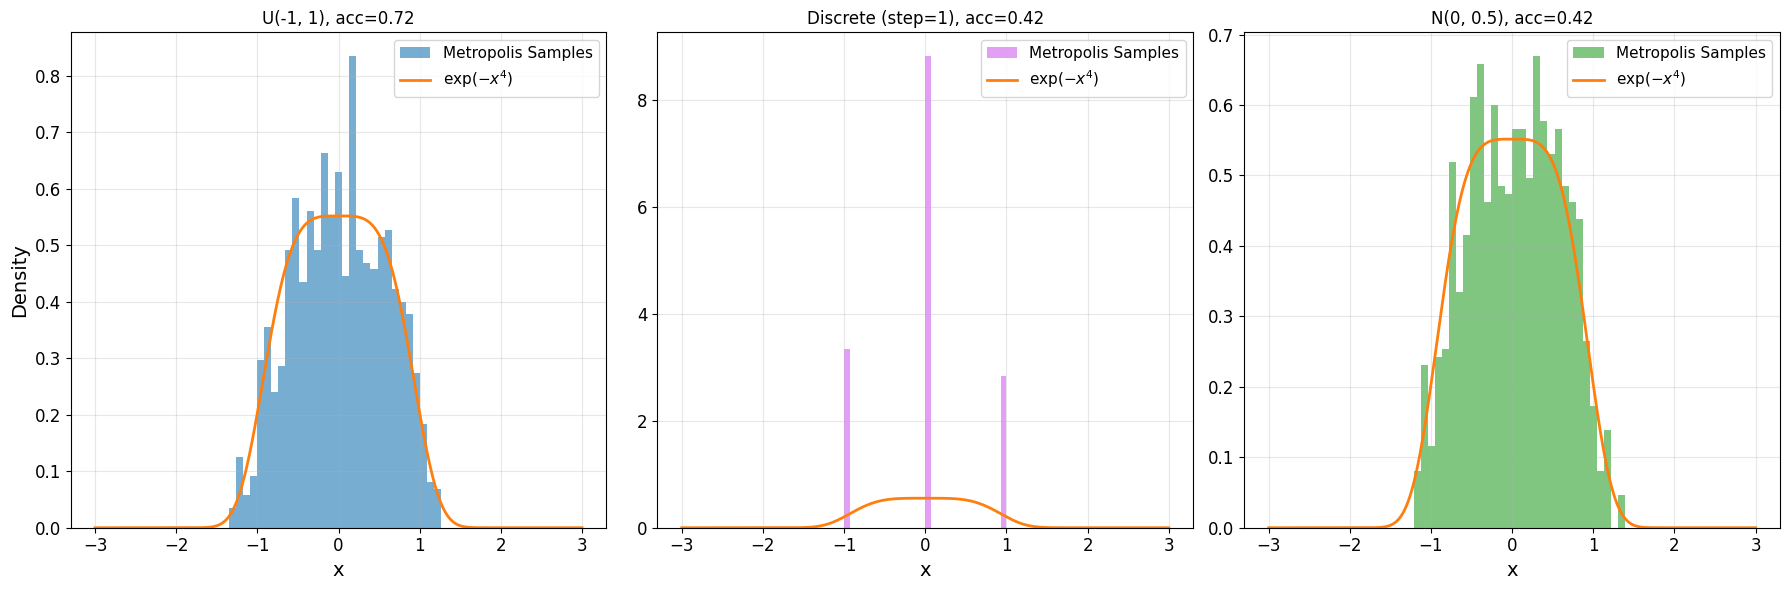

In [353]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# ---------- First plot ----------
ax[0].hist(samples_uniform, bins=B1, density=True,
           alpha=0.6, color=UNIFORM_COLOR,
           label="Metropolis Samples")

ax[0].plot(x_vals, true_density, linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label=r'$\exp(-x^4)$')

ax[0].set_title(f"U(-{UNIFORM_STEP}, {UNIFORM_STEP}), acc={acc_uniform:.2f}")
ax[0].set_xlabel("x", fontsize=LABEL_SIZE)
ax[0].set_ylabel("Density", fontsize=LABEL_SIZE)
ax[0].tick_params(axis='both', labelsize=TICK_SIZE)
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=LEGEND_SIZE)

# ---------- Second plot ----------
ax[1].hist(samples_discrete, bins=B2, density=True,
           alpha=0.6, color=DISCRETE_COLOR,
           label="Metropolis Samples")

ax[1].plot(x_vals, true_density, linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label=r'$\exp(-x^4)$')

ax[1].set_title(f"Discrete (step={DISCRETE_STEP}), acc={acc_discrete:.2f}")
ax[1].set_xlabel("x", fontsize=LABEL_SIZE)
ax[1].tick_params(axis='both', labelsize=TICK_SIZE)
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=LEGEND_SIZE)

# ---------- Third plot ----------
ax[2].hist(samples_normal,
           bins=B3, density=True, alpha=0.6,
           color=NORMAL_COLOR,
           label="Metropolis Samples")

ax[2].plot(x_vals, true_density, linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label=r'$\exp(-x^4)$')

ax[2].set_title(f"N(0, {SIGMA}), acc={acc_discrete:.2f}")
ax[2].set_xlabel("x", fontsize=LABEL_SIZE)
ax[2].tick_params(axis='both', labelsize=TICK_SIZE)
ax[2].grid(True, alpha=0.3)
ax[2].legend(fontsize=LEGEND_SIZE)

# Better spacing
plt.tight_layout()
plt.show()

### Save figures separately

In [354]:
plot_name = {"Uniform": f"Uniform(-{UNIFORM_STEP}, {UNIFORM_STEP})",
             "Discrete":f"discrete (Step={DISCRETE_STEP})",
             "Normal": f"Normal(0, {SIGMA})"}

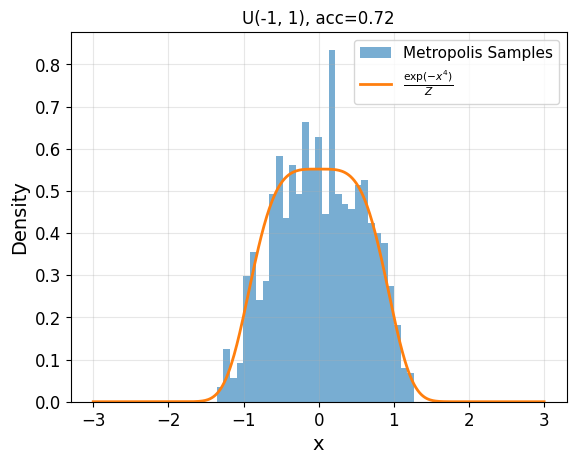

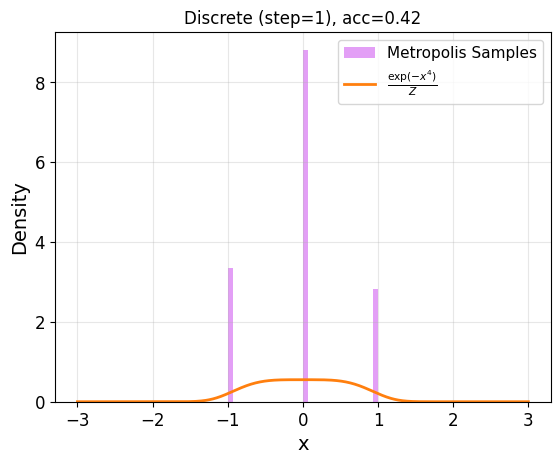

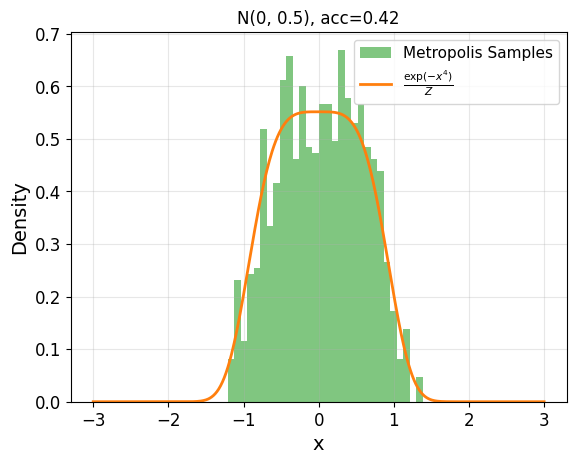

In [355]:
# ---------- First plot ----------
plt.hist(samples_uniform, bins=B1, density=True,
           alpha=0.6, color=UNIFORM_COLOR,
           label="Metropolis Samples")

plt.plot(x_vals, true_density, linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label=r'$\frac{\exp(-x^4)}{Z}$')

plt.title(f"U(-{UNIFORM_STEP}, {UNIFORM_STEP}), acc={acc_uniform:.2f}")
plt.xlabel("x", fontsize=LABEL_SIZE)
plt.ylabel("Density", fontsize=LABEL_SIZE)
plt.tick_params(axis='both', labelsize=TICK_SIZE)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=LEGEND_SIZE)
plt.savefig(f"../../Figures/uniform_proposal_2b", dpi=800)
plt.show()

# ---------- Second plot ----------
plt.hist(samples_discrete, bins=B2, density=True,
           alpha=0.6, color=DISCRETE_COLOR,
           label="Metropolis Samples")

plt.plot(x_vals, true_density, linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label=r'$\frac{\exp(-x^4)}{Z}$')

plt.title(f"Discrete (step={DISCRETE_STEP}), acc={acc_discrete:.2f}")
plt.xlabel("x", fontsize=LABEL_SIZE)
plt.ylabel("Density", fontsize=LABEL_SIZE)
plt.tick_params(axis='both', labelsize=TICK_SIZE)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=LEGEND_SIZE)
plt.savefig(f"../../Figures/discrete_proposal_2b", dpi=800)
plt.show()

# ---------- Third plot ----------
plt.hist(samples_normal,
           bins=B3, density=True, alpha=0.6,
           color=NORMAL_COLOR,
           label="Metropolis Samples")

plt.plot(x_vals, true_density, linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label=r'$\frac{\exp(-x^4)}{Z}$')

plt.title(f"N(0, {SIGMA}), acc={acc_discrete:.2f}")
plt.xlabel("x", fontsize=LABEL_SIZE)
plt.ylabel("Density", fontsize=LABEL_SIZE)
plt.tick_params(axis='both', labelsize=TICK_SIZE)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=LEGEND_SIZE)
plt.savefig(f"../../Figures/normal_proposal_2b", dpi=800)
plt.show()

## Trace plots

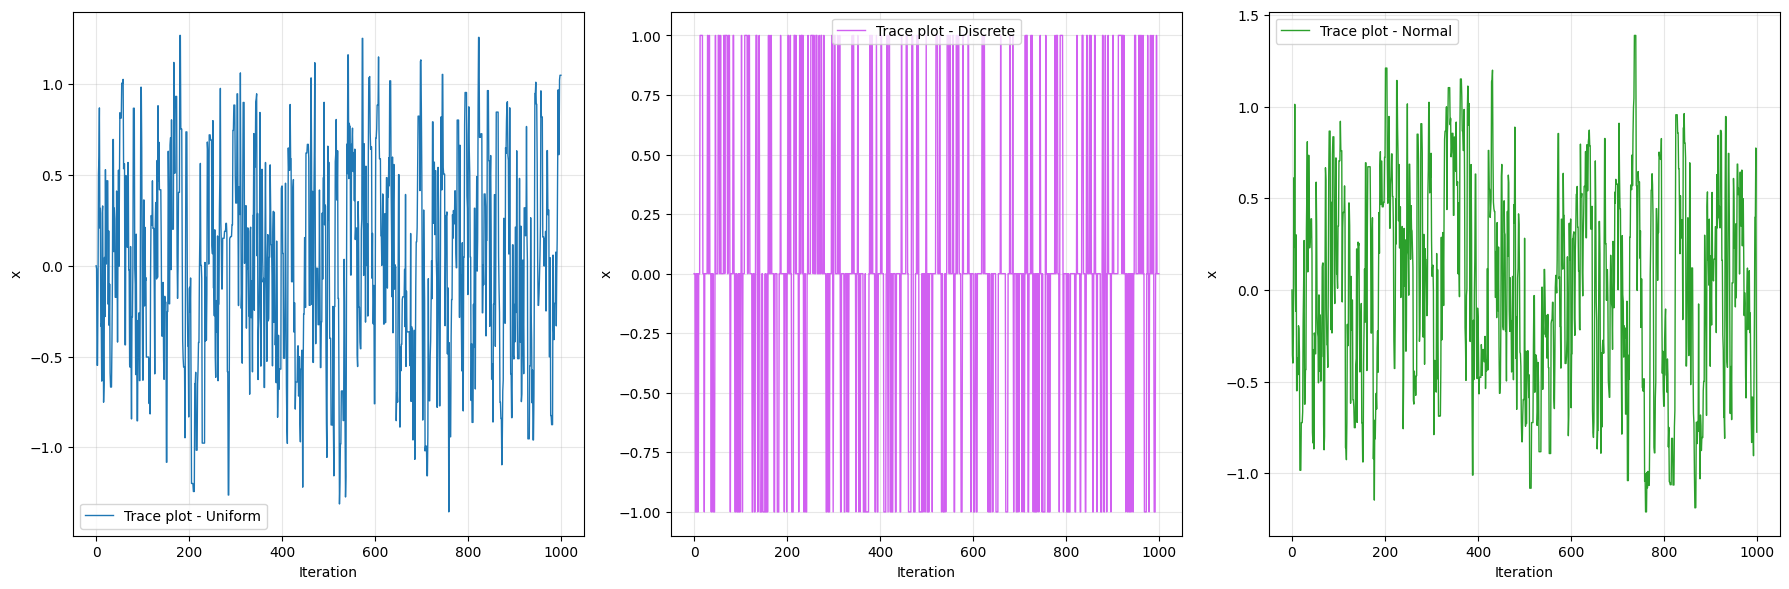

In [356]:
PROPOSAL_COLORS = {
    "Uniform": UNIFORM_COLOR,
    "Discrete": DISCRETE_COLOR,
    "Normal": NORMAL_COLOR,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]
    ax.plot(samples, linewidth=1, color=PROPOSAL_COLORS[proposal_name], label=f"Trace plot - {proposal_name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("x")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Save figures

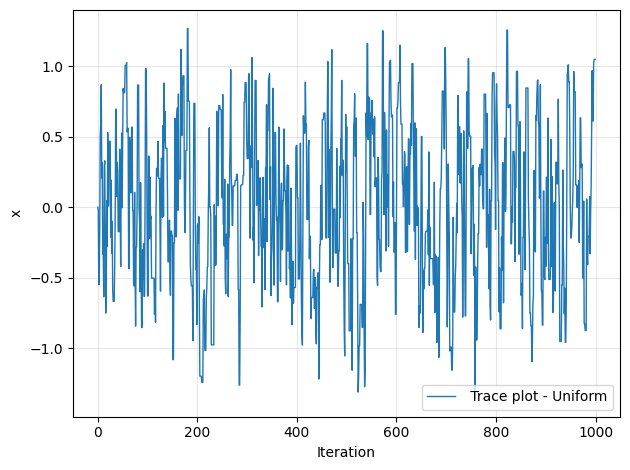

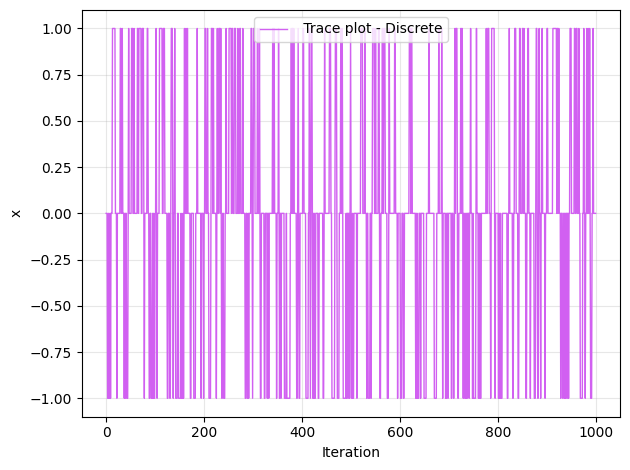

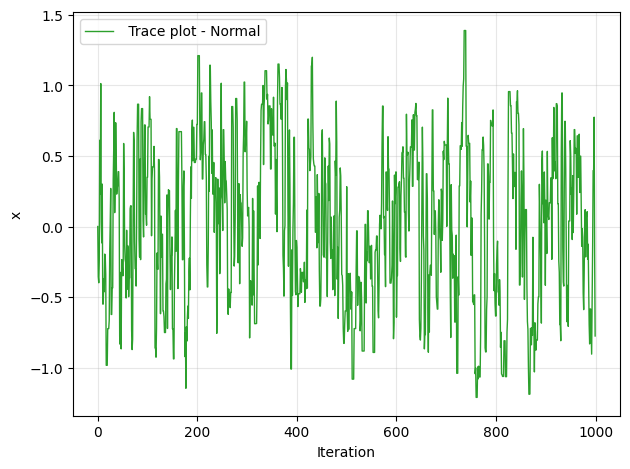

In [357]:
for proposal_name, result in metropolis_results.items():
    samples = result["samples"]

    plt.plot(samples, linewidth=1, color=PROPOSAL_COLORS[proposal_name], label=f" Trace plot - {proposal_name}")
    plt.xlabel("Iteration")
    plt.ylabel("x")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../../Figures/trace_plot_{proposal_name}_2c", dpi=800)
    plt.show()


## Running mean convergence
Since f(x) is symmetric around 0, the true mean is 0. The running mean should move toward 0 if sampling works well.

Uniform sample mean: 0.0190
Discrete sample mean: -0.0340
Normal sample mean: 0.0303


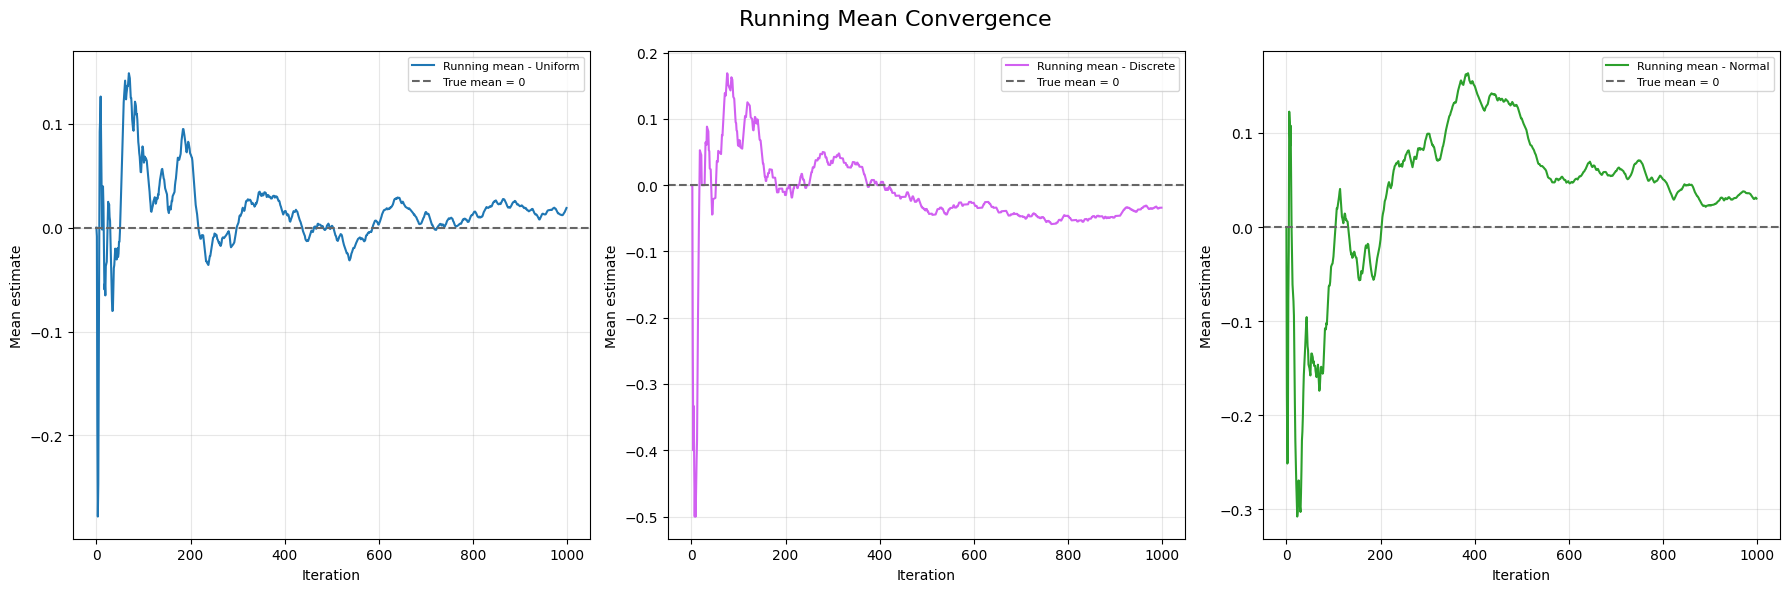

In [358]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]
    running_mean = np.cumsum(samples) / np.arange(1, len(samples) + 1)

    ax.plot(running_mean, linewidth=1.5, color=PROPOSAL_COLORS[proposal_name], label=f"Running mean - {proposal_name}")
    ax.axhline(0, linestyle="--", linewidth=1.5, color="#666666", label="True mean = 0")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean estimate")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    sample_mean = np.mean(samples)
    print(f"{proposal_name} sample mean: {sample_mean:.4f}")
    
plt.suptitle("Running Mean Convergence", fontsize=16)
plt.tight_layout()
plt.show()

### Save figures

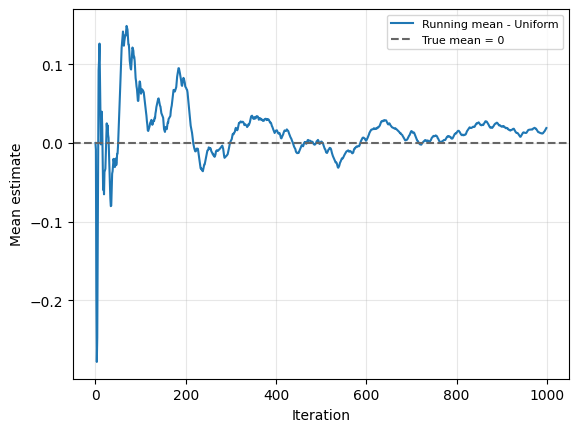

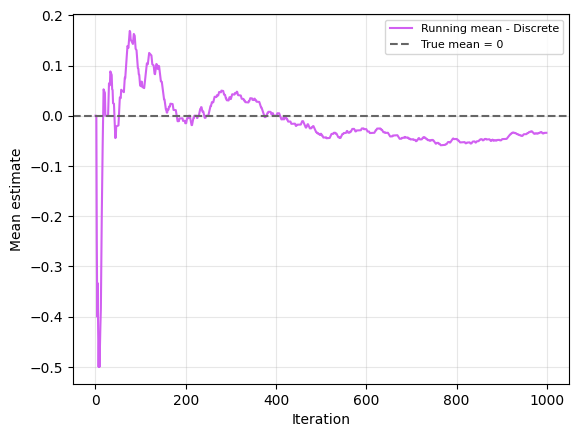

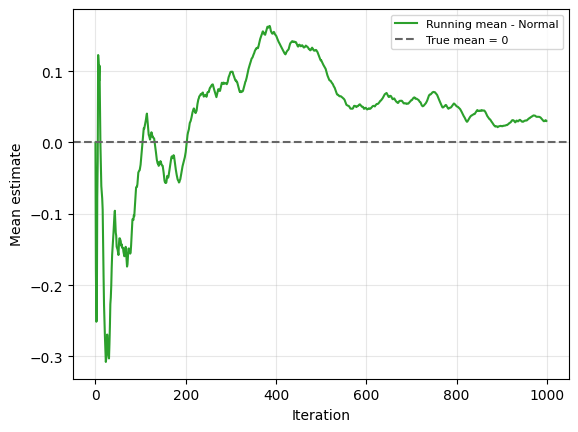

In [359]:
for proposal_name, result in metropolis_results.items():

    samples = result["samples"]
    running_mean = np.cumsum(samples) / np.arange(1, len(samples) + 1)

    plt.plot(running_mean, linewidth=1.5, color=PROPOSAL_COLORS[proposal_name], label=f"Running mean - {proposal_name}")
    plt.axhline(0, linestyle="--", linewidth=1.5, color="#666666", label="True mean = 0")
    plt.xlabel("Iteration")
    plt.ylabel("Mean estimate")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.savefig(f"../../Figures/running_mean_{proposal_name}_2c", dpi=800)
    plt.show()

## Autocorrelation function
Lower autocorrelation usually means better mixing. If autocorrelation stays high, samples are strongly dependent.

In [360]:
def autocorrelation(samples, max_lag=50):
    """
    Compute autocorrelation values up to max_lag.
    """

    samples = np.asarray(samples)
    samples_centered = samples - np.mean(samples)

    acf_values = []

    for lag in range(max_lag + 1):

        if lag == 0:
            acf_values.append(1.0)
        else:
            corr = np.corrcoef(
                samples_centered[:-lag],
                samples_centered[lag:]
            )[0, 1]
            acf_values.append(corr)

    return np.array(acf_values)

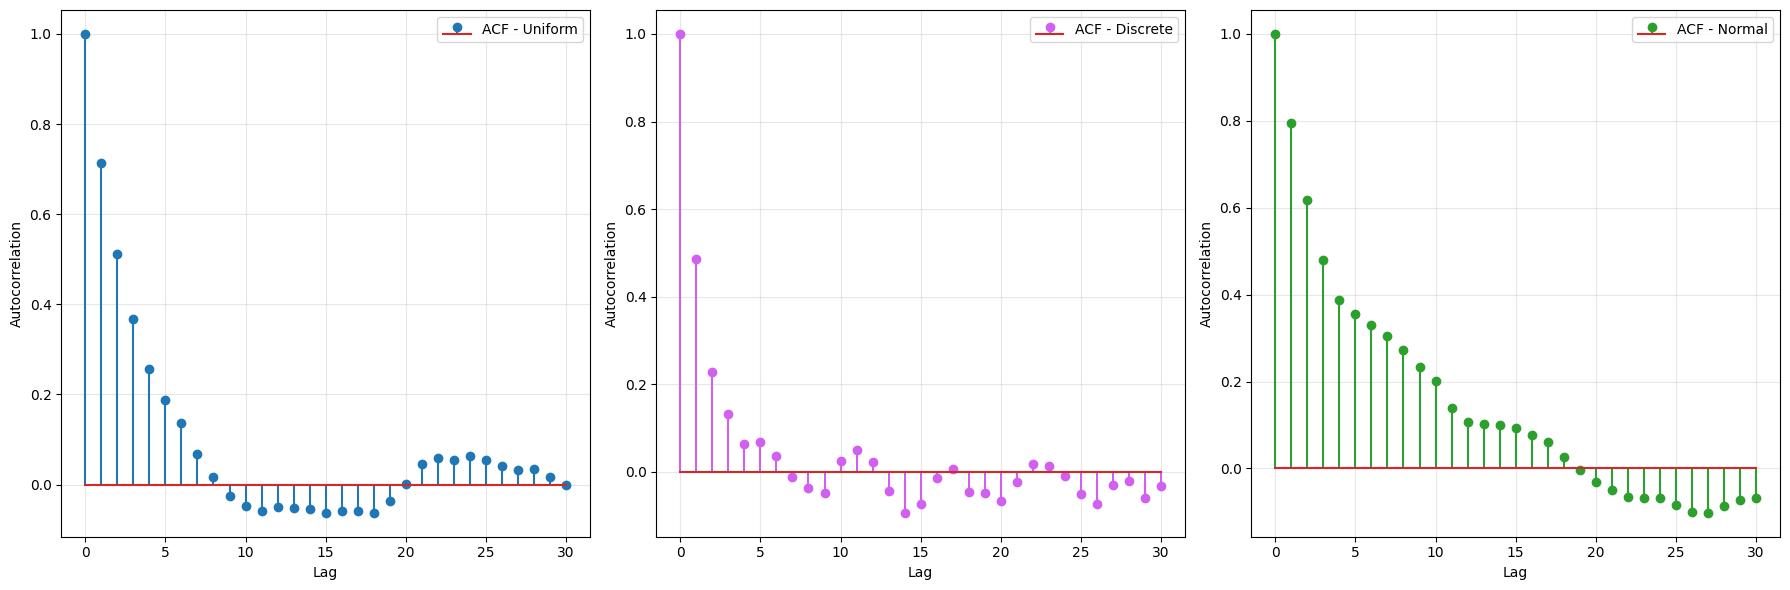

In [361]:
max_lag = 30


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (proposal_name, result) in zip(axes, metropolis_results.items()):

    samples = result["samples"]
    acf_values = autocorrelation(samples, max_lag=max_lag)

    markerline, stemlines, baseline = ax.stem(
        range(max_lag + 1),
        acf_values, label=f'ACF - {proposal_name}'
    )
    plt.setp(markerline, color=PROPOSAL_COLORS[proposal_name])
    plt.setp(stemlines, color=PROPOSAL_COLORS[proposal_name])
    ax.legend()

    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()

### Save figures

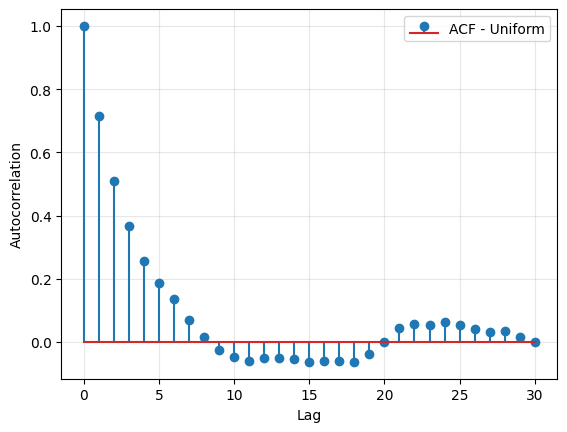

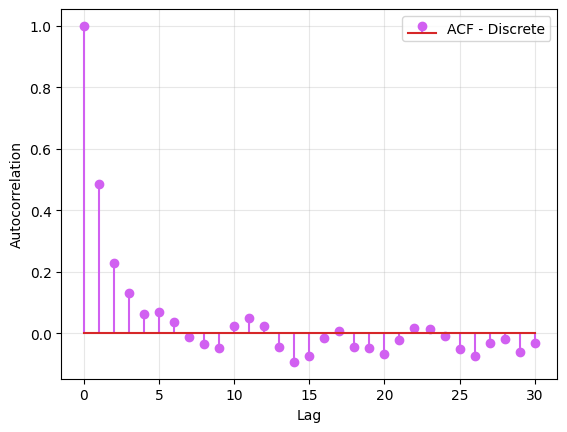

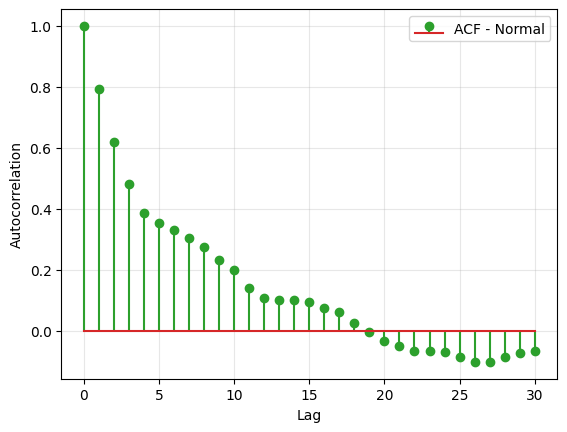

In [362]:
for proposal_name, result in metropolis_results.items():

    samples = result["samples"]
    acf_values = autocorrelation(samples, max_lag=max_lag)

    markerline, stemlines, baseline = plt.stem(
        range(max_lag + 1),
        acf_values, label=f'ACF - {proposal_name}'
    )
    plt.setp(markerline, color=PROPOSAL_COLORS[proposal_name])
    plt.setp(stemlines, color=PROPOSAL_COLORS[proposal_name])
    plt.legend()

    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.grid(True, alpha=0.3)
    plt.savefig(f"../../Figures/acf_{proposal_name}_2c")
    plt.show()

## Numerical performance table

In [363]:
performance_rows = []

# Theoretical moment values
true_mean = 0.0
true_fourth_moment = 1 / 4

def distribution_l1_error(samples, bins=80, x_range=(-3, 3)):
    """
    Measures how close the sampled histogram is to the true density
    based on MidPoint Riemann Sum
    Smaller value means better convergence.
    """

    hist_density, bin_edges = np.histogram(
        samples,
        bins=bins,
        range=x_range,
        density=True
    )

    # Average sum of left points and end points
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    true_vals = target_fn(bin_centers, Z)
    dx = bin_edges[1] - bin_edges[0]
    l1_error = np.sum(np.abs(hist_density - true_vals)) * dx

    return l1_error

for proposal_name, result in metropolis_results.items():

    samples = result["samples"]
    acceptance_rate = result["acceptance_rate"]

    sample_mean = np.mean(samples)
    sample_variance = np.var(samples)
    sample_fourth_moment = np.mean(samples**4)

    mean_abs_error = abs(sample_mean - true_mean)
    fourth_moment_abs_error = abs(sample_fourth_moment - true_fourth_moment)

    distribution_error = distribution_l1_error(samples)

    performance_rows.append({
        "Proposal": proposal_name,
        "Acceptance Rate": acceptance_rate,
        "Sample Mean": sample_mean,
        "Mean Absolute Error": mean_abs_error,
        "Sample Variance": sample_variance,
        "Sample E[X^4]": sample_fourth_moment,
        "True E[X^4]": true_fourth_moment,
        "E[X^4] Absolute Error": fourth_moment_abs_error,
        "Distribution L1 Error": distribution_error
    })

performance_table = pd.DataFrame(performance_rows)
performance_table.sort_values(by="Distribution L1 Error", ascending=True, inplace=True)
performance_table

,Proposal,Acceptance Rate,Sample Mean,Mean Absolute Error,Sample Variance,Sample E[X^4],True E[X^4],E[X^4] Absolute Error,Distribution L1 Error
2,Normal,0.779780,0.030252,0.030252,0.324374,0.225026,0.25,0.024974,0.175181
0,Uniform,0.719720,0.018957,0.018957,0.327526,0.237254,0.25,0.012746,0.208940
1,Discrete,0.422422,-0.034000,0.034000,0.410844,0.412000,0.25,0.162000,1.859399


## Acceptance Rate across Proposal Distributions

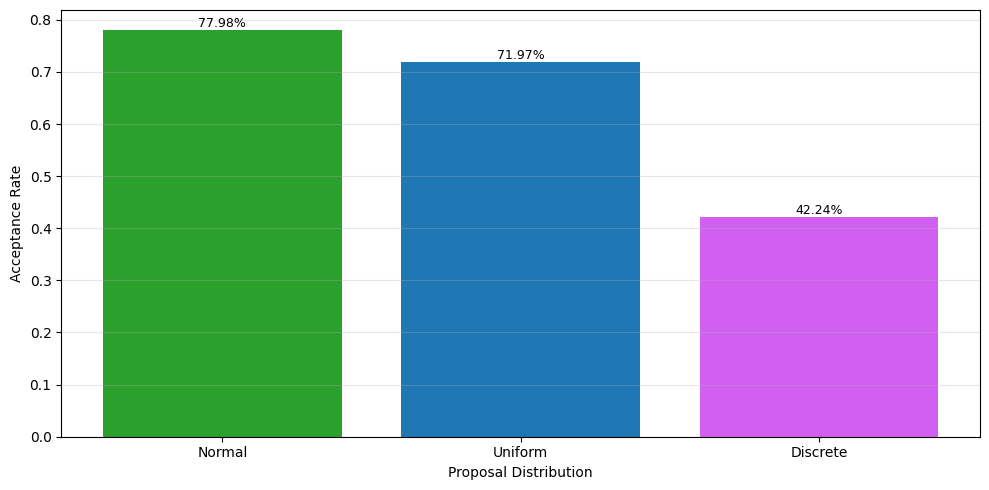

In [364]:
# Acceptance Rate Comparison
plt.figure(figsize=(10, 5))
plt.bar(performance_table["Proposal"],
      performance_table["Acceptance Rate"],
      color=[PROPOSAL_COLORS.get(p) for p in performance_table["Proposal"]]
)

plt.xlabel("Proposal Distribution")
plt.ylabel("Acceptance Rate")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(performance_table["Acceptance Rate"]):
    plt.text(i, value, f"{value:.2%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(
    "../../Figures/acp_rate_comparison_2c.png", dpi=800, bbox_inches="tight"
)
plt.show()

**Remarks:** Among the three methods, the Normal proposal achieved the lowest distribution L1 error, indicating the best overall sampling efficiency. In contrast, the discrete proposal consistently produced the worst performance across all evaluation metrics, including distribution L1 error and moment estimation accuracy.

## Extra Exploration

We then investigated how the performance of the three proposals evolved as the number of samples increased up to N=10,000. Both the Uniform and Normal proposals exhibited clear convergence behavior, with their distribution errors decreasing steadily as N increased. However, the discrete proposal showed substantially slower trend and did not converge.

### Comparison of distribution as N increases

In [365]:
# ============================================================
# Further Exploration:
# Convergence comparison as N increases
# ============================================================

import contextlib
import io

# Discrete N values: 10, 100, 200, 300, ..., 10000
N_values = np.concatenate(([100], np.arange(100, 10001, 100)))


# Histogram settings for measuring distribution error
ERROR_BINS = 80
ERROR_RANGE = (-3, 3)

def distribution_l1_error(samples, bins=ERROR_BINS, x_range=ERROR_RANGE):
    """
    Compare empirical sampled distribution with the true density.
    Smaller L1 error means the sampled distribution is closer to the true distribution.
    """

    hist_density, bin_edges = np.histogram(
        samples,
        bins=bins,
        range=x_range,
        density=True
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dx = bin_edges[1] - bin_edges[0]

    true_vals = target_fn(bin_centers, Z)

    l1_error = np.sum(np.abs(hist_density - true_vals)) * dx

    return l1_error


convergence_rows = []

for N_current in N_values:

    # Suppress acceptance-rate printing from universal_metropolis_sampler
    with contextlib.redirect_stdout(io.StringIO()):

        samples_uniform, acc_uniform = universal_metropolis_sampler(
            dist="uniform",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=UNIFORM_STEP
        )

        samples_discrete, acc_discrete = universal_metropolis_sampler(
            dist="discrete",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=DISCRETE_STEP
        )

        samples_normal, acc_normal = universal_metropolis_sampler(
            dist="normal",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            sigma=SIGMA
        )

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Uniform",
        "Distribution Error": distribution_l1_error(samples_uniform),
        "Acceptance Rate": acc_uniform
    })

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Discrete",
        "Distribution Error": distribution_l1_error(samples_discrete),
        "Acceptance Rate": acc_discrete
    })

    convergence_rows.append({
        "N": N_current,
        "Proposal": "Normal",
        "Distribution Error": distribution_l1_error(samples_normal),
        "Acceptance Rate": acc_normal
    })


convergence_df = pd.DataFrame(convergence_rows)

convergence_df.head()

,N,Proposal,Distribution Error,Acceptance Rate
0,100,Uniform,0.635293,0.717172
1,100,Discrete,1.859399,0.464646
2,100,Normal,0.508108,0.818182
3,100,Uniform,0.627131,0.707071
4,100,Discrete,1.859399,0.434343


## Convergence of Metropolis Sampling as N Increases

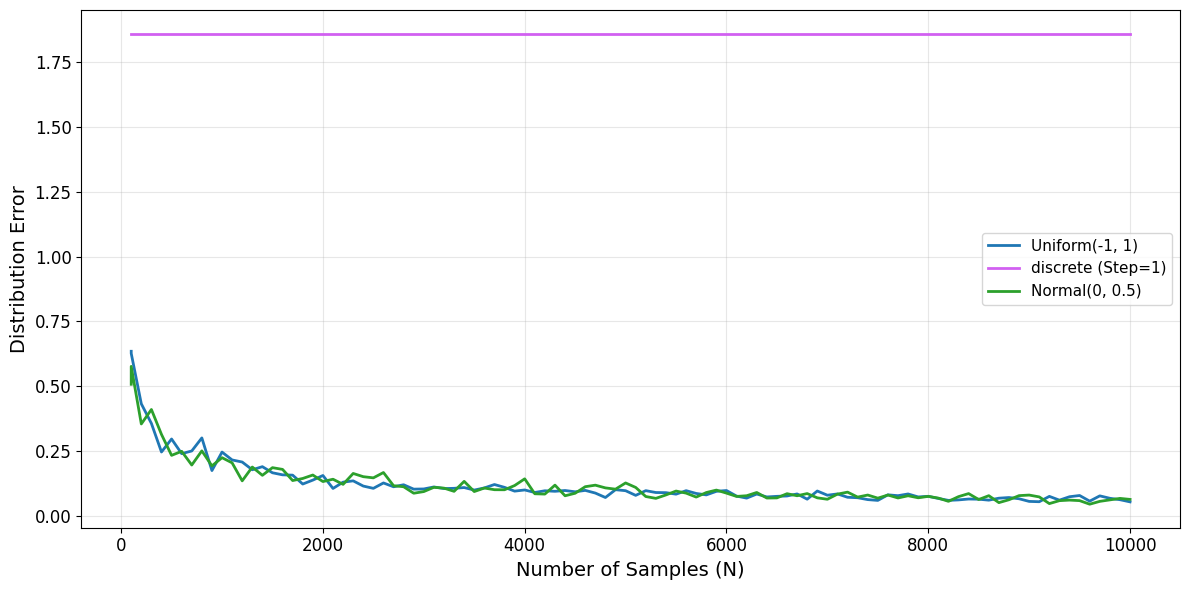

In [366]:
# ============================================================
# Plot convergence comparison
# ============================================================

PROPOSAL_COLORS = {
    "Uniform": UNIFORM_COLOR,
    "Discrete": DISCRETE_COLOR,
    "Normal": NORMAL_COLOR,
}

fig, ax = plt.subplots(figsize=(12, 6))

for proposal_name in ["Uniform", "Discrete", "Normal"]:

    proposal_df = convergence_df[
        convergence_df["Proposal"] == proposal_name
    ]

    ax.plot(
        proposal_df["N"],
        proposal_df["Distribution Error"],
        linewidth=2,
        color=PROPOSAL_COLORS[proposal_name],
        label=plot_name[proposal_name]
    )

ax.set_xlabel("Number of Samples (N)", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "../../Figures/convergence_comparison_2d.png",
    format="png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The running mean of the discrete sampler did not stabilize satisfactorily even at large sample sizes, suggesting poor mixing and strong sample autocorrelation. Therefore, we further tuned the proposal parameters of all three methods to examine whether the discrete sampler could be improved relative to the Uniform and Normal proposals.

## Best Step Size from np.linspace(0.0001, 1, 100)

In [367]:
import contextlib
import io

N = 10000
INITIAL_X = 0.0

# Try different fixed random-walk step sizes
STEP_VALUES = np.linspace(0.0001, 1, 100)

### Discrete: 0.0809

In [368]:
# How to make discrete proposal more efficient?
# ============================================================
# Further Exploration:
# Compare Different discrete Step Sizes
# ============================================================
discrete_step_results = []

for step in STEP_VALUES:
    with contextlib.redirect_stdout(io.StringIO()):
        samples_discrete, acc_discrete = universal_metropolis_sampler(
            dist="discrete",
            num_samples=N,
            initial_x=INITIAL_X,
            z=Z,
            step_size=step
        )

    mean_estimate = np.mean(samples_discrete)
    fourth_moment_estimate = np.mean(samples_discrete**4)

    mean_error = abs(mean_estimate - 0)
    fourth_moment_error = abs(fourth_moment_estimate - 0.25)
    dist_error = distribution_l1_error(samples_discrete)

    discrete_step_results.append({
        "Step Size": step,
        "Acceptance Rate": acc_discrete,
        "Mean Estimate": mean_estimate,
        "Mean Error": mean_error,
        "E[X^4] Estimate": fourth_moment_estimate,
        "E[X^4] Error": fourth_moment_error,
        "Distribution Error": dist_error
    })


discrete_step_df = pd.DataFrame(discrete_step_results)
discrete_step_df.sort_values(by=["Distribution Error"], ascending=True)

,Step Size,Acceptance Rate,Mean Estimate,Mean Error,E[X^4] Estimate,E[X^4] Error,Distribution Error
7,0.0708,0.960096,0.001487,0.001487,0.254873,0.004873,0.115321
8,0.0809,0.952395,-0.009384,0.009384,0.246560,0.003440,0.174476
3,0.0304,0.986899,0.041232,0.041232,0.184873,0.065127,0.294680
6,0.0607,0.970597,0.083074,0.083074,0.215057,0.034943,0.316431
5,0.0506,0.970197,0.007575,0.007575,0.232057,0.017943,0.337910
...,...,...,...,...,...,...,...
94,0.9495,0.473547,0.008830,0.008830,0.373641,0.123641,1.840821
96,0.9697,0.447145,-0.008242,0.008242,0.399392,0.149392,1.840821
98,0.9899,0.434643,0.023659,0.023659,0.416058,0.166058,1.859399
97,0.9798,0.445245,0.007936,0.007936,0.411133,0.161133,1.859399


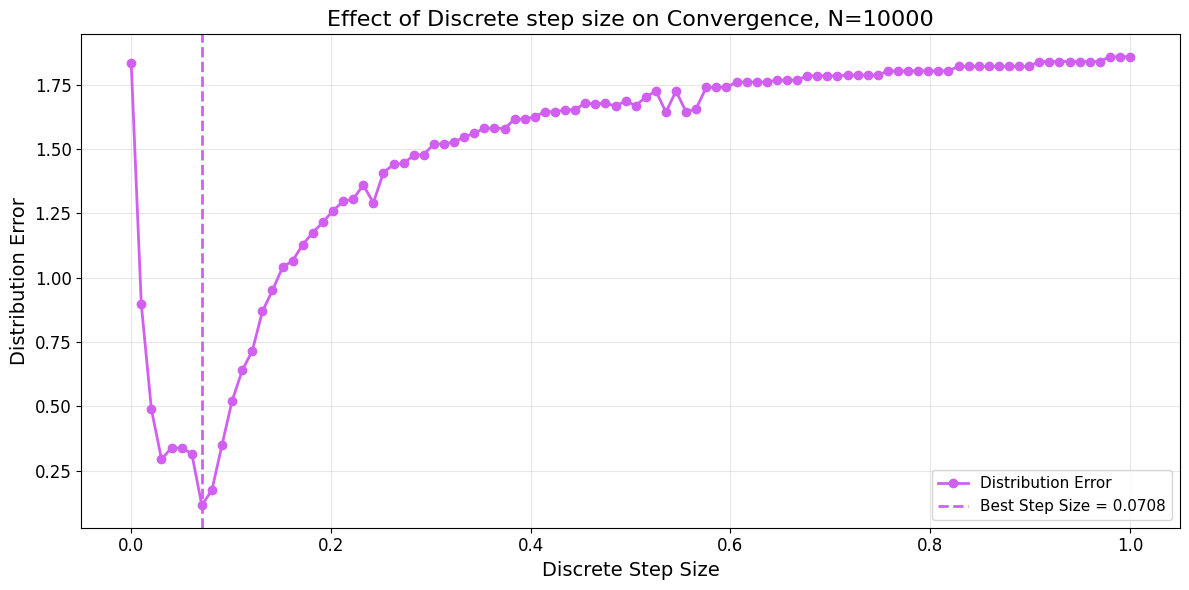

Best step size: 0.0708
Lowest distribution error: 0.115321


In [369]:
# ============================================================
# Plot: Discrete Step Size vs Distribution Error
# ============================================================

best_row = discrete_step_df.loc[discrete_step_df["Distribution Error"].idxmin()]
best_step = best_row["Step Size"]
best_error = best_row["Distribution Error"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    discrete_step_df["Step Size"],
    discrete_step_df["Distribution Error"],
    marker="o", color=DISCRETE_COLOR,
    linewidth=2, label="Distribution Error"
)

ax.axvline(
    best_step, linestyle="--", 
    linewidth=2, color=DISCRETE_COLOR,
    label=f"Best Step Size = {best_step}"
)

ax.set_title(
    f"Effect of Discrete step size on Convergence, N={N}",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Discrete Step Size", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "../../Figures/best_discrete_step_2e.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Best step size: {best_step}")
print(f"Lowest distribution error: {best_error:.6f}")

### Uniform Step size = 0.2728

In [370]:
uniform_step_results = []

for step in STEP_VALUES:
    with contextlib.redirect_stdout(io.StringIO()):
        samples_uniform, acc_uniform = universal_metropolis_sampler(
            dist="uniform",
            num_samples=N,
            initial_x=INITIAL_X,
            z=Z,
            step_size=step
        )

    mean_estimate = np.mean(samples_uniform)
    fourth_moment_estimate = np.mean(samples_uniform**4)

    mean_error = abs(mean_estimate - 0)
    fourth_moment_error = abs(fourth_moment_estimate - 0.25)
    dist_error = distribution_l1_error(samples_uniform)

    uniform_step_results.append({
        "Step Size": step,
        "Acceptance Rate": acc_uniform,
        "Mean Estimate": mean_estimate,
        "Mean Error": mean_error,
        "E[X^4] Estimate": fourth_moment_estimate,
        "E[X^4] Error": fourth_moment_error,
        "Distribution Error": dist_error
    })


uniform_step_df = pd.DataFrame(uniform_step_results)
uniform_step_df.sort_values(by=["Distribution Error"], ascending=True)

,Step Size,Acceptance Rate,Mean Estimate,Mean Error,E[X^4] Estimate,E[X^4] Error,Distribution Error
75,0.7576,0.798380,-0.005847,0.005847,2.451095e-01,0.004891,0.046329
83,0.8384,0.768577,0.008466,0.008466,2.546063e-01,0.004606,0.048116
82,0.8283,0.771977,0.007707,0.007707,2.475092e-01,0.002491,0.048607
59,0.5960,0.840284,-0.001734,0.001734,2.382445e-01,0.011756,0.050511
58,0.5859,0.835784,0.001178,0.001178,2.599063e-01,0.009906,0.051804
...,...,...,...,...,...,...,...
9,0.0910,0.974897,-0.278730,0.278730,2.328501e-01,0.017150,0.433193
4,0.0405,0.978298,-0.543157,0.543157,6.142235e-01,0.364224,0.903756
2,0.0203,0.991599,0.626826,0.626826,3.835903e-01,0.133590,1.049379
1,0.0102,0.999700,0.175779,0.175779,1.408179e-02,0.235918,1.135769


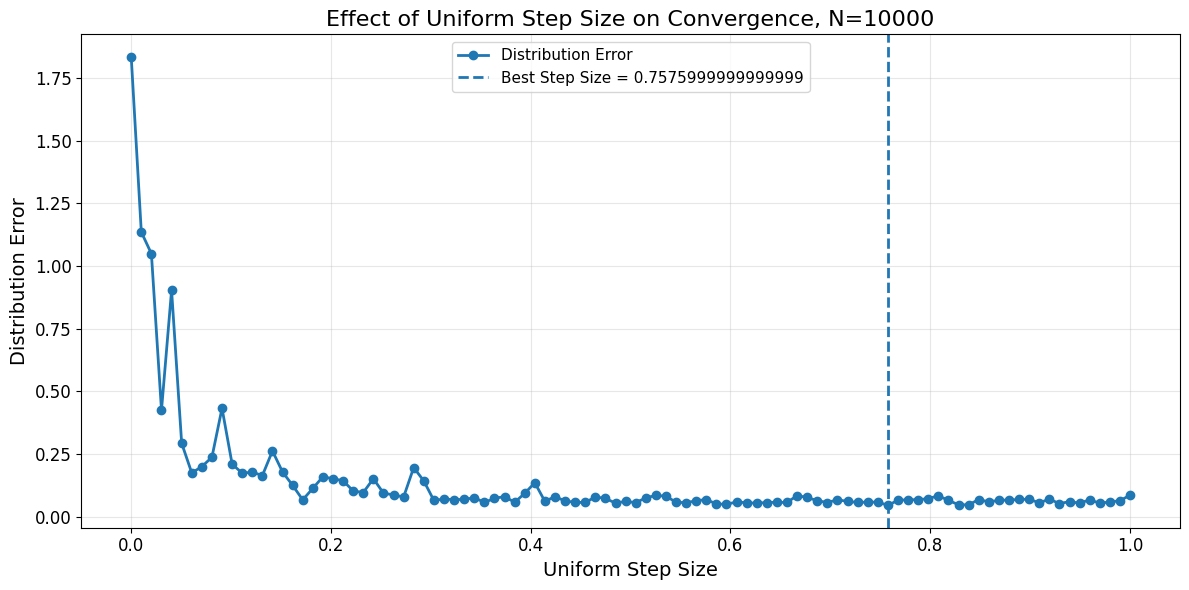

Best step size: 0.7575999999999999
Lowest distribution error: 0.046329


In [371]:
# ============================================================
# Plot: Uniform Step Size vs Distribution Error
# ============================================================

best_row = uniform_step_df.loc[uniform_step_df["Distribution Error"].idxmin()]
best_step = best_row["Step Size"]
best_error = best_row["Distribution Error"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    uniform_step_df["Step Size"],
    uniform_step_df["Distribution Error"],
    marker="o", color=UNIFORM_COLOR,
    linewidth=2,
    label="Distribution Error"
)

ax.axvline(
    best_step, linestyle="--",
    linewidth=2, color=UNIFORM_COLOR,
    label=f"Best Step Size = {best_step}"
)

ax.set_title(
    f"Effect of Uniform Step Size on Convergence, N={N}",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Uniform Step Size", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "../../Figures/best_uniform_step_2e.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Best step size: {best_step}")
print(f"Lowest distribution error: {best_error:.6f}")

### Normal Std = 0.6263

In [372]:
normal_step_results = []

for step in STEP_VALUES:
    with contextlib.redirect_stdout(io.StringIO()):
        samples_normal, acc_normal = universal_metropolis_sampler(
            dist="normal",
            num_samples=N,
            initial_x=INITIAL_X,
            z=Z,
            sigma=step
        )

    mean_estimate = np.mean(samples_normal)
    fourth_moment_estimate = np.mean(samples_normal**4)

    mean_error = abs(mean_estimate - 0)
    fourth_moment_error = abs(fourth_moment_estimate - 0.25)
    dist_error = distribution_l1_error(samples_normal)

    normal_step_results.append({
        "Step Size": step,
        "Acceptance Rate": acc_normal,
        "Mean Estimate": mean_estimate,
        "Mean Error": mean_error,
        "E[X^4] Estimate": fourth_moment_estimate,
        "E[X^4] Error": fourth_moment_error,
        "Distribution Error": dist_error
    })


normal_step_df = pd.DataFrame(normal_step_results)
normal_step_df.sort_values(by=["Distribution Error"], ascending=True)

,Step Size,Acceptance Rate,Mean Estimate,Mean Error,E[X^4] Estimate,E[X^4] Error,Distribution Error
78,0.7879,0.666467,-0.006291,0.006291,2.414250e-01,0.008575,0.044521
46,0.4647,0.794179,0.009894,0.009894,2.446548e-01,0.005345,0.051928
27,0.2728,0.882588,0.017423,0.017423,2.413562e-01,0.008644,0.052792
70,0.7071,0.694269,0.014353,0.014353,2.546804e-01,0.004680,0.052820
63,0.6364,0.723272,-0.002234,0.002234,2.682698e-01,0.018270,0.054511
...,...,...,...,...,...,...,...
5,0.0506,0.984898,-0.100536,0.100536,1.372963e-01,0.112704,0.228199
3,0.0304,0.990699,-0.155958,0.155958,1.872980e-01,0.062702,0.496384
2,0.0203,0.986899,0.526686,0.526686,3.848802e-01,0.134880,0.854072
1,0.0102,0.989799,-0.818279,0.818279,7.520477e-01,0.502048,1.295222


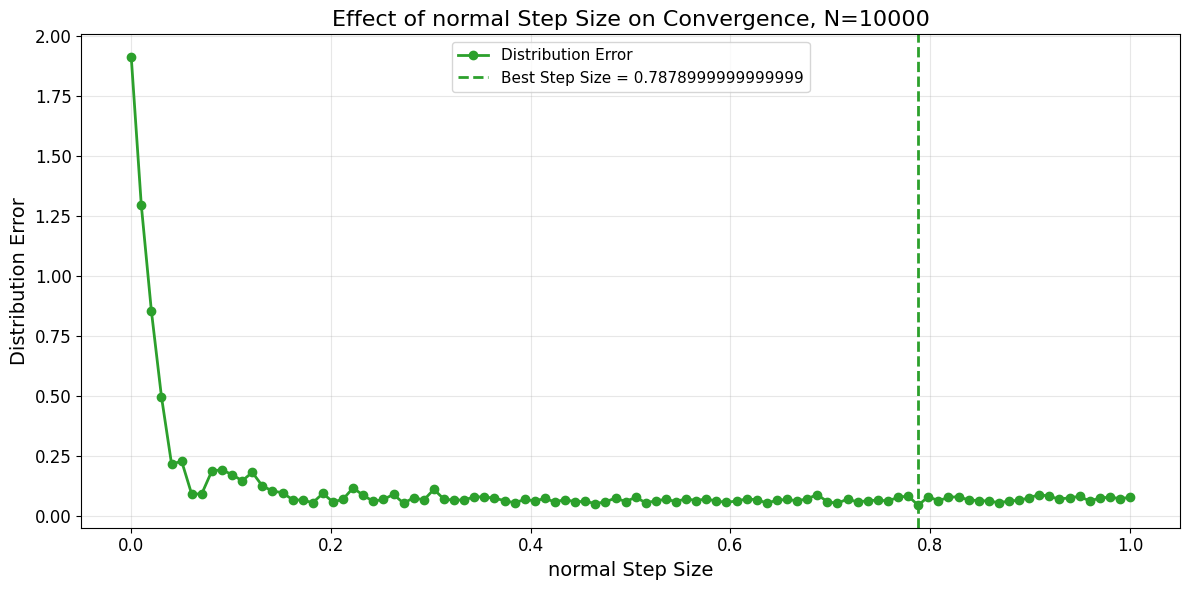

Best step size: 0.7878999999999999
Lowest distribution error: 0.044521


In [373]:
# ============================================================
# Plot: Uniform Step Size vs Distribution Error
# ============================================================

best_row = normal_step_df.loc[normal_step_df["Distribution Error"].idxmin()]
best_step = best_row["Step Size"]
best_error = best_row["Distribution Error"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    normal_step_df["Step Size"],
    normal_step_df["Distribution Error"],
    marker="o", color=NORMAL_COLOR,
    linewidth=2,
    label="Distribution Error"
)

ax.axvline(
    best_step, linestyle="--",
    linewidth=2, color=NORMAL_COLOR,
    label=f"Best Step Size = {best_step}"
)

ax.set_title(
    f"Effect of normal Step Size on Convergence, N={N}",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("normal Step Size", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "../../Figures/best_normal_step_2e.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Best step size: {best_step}")
print(f"Lowest distribution error: {best_error:.6f}")

## Best performance table

In [374]:
row1

,Step Size,Acceptance Rate,Mean Estimate,Mean Error,E[X^4] Estimate,E[X^4] Error,Distribution Error
78,0.7879,0.666467,-0.006291,0.006291,0.241425,0.008575,0.044521


In [375]:
# take first row from each table
row1 = normal_step_df.loc[[normal_step_df["Distribution Error"].idxmin()]]
row2 = uniform_step_df.loc[[uniform_step_df["Distribution Error"].idxmin()]]
row3 = discrete_step_df.loc[[discrete_step_df["Distribution Error"].idxmin()]]

# merge into one table
final_table = pd.concat([row1, row2, row3], ignore_index=True)
final_table.index = ["Normal", "Uniform", "Discrete"]

display(final_table)

,Step Size,Acceptance Rate,Mean Estimate,Mean Error,E[X^4] Estimate,E[X^4] Error,Distribution Error
Normal,0.7879,0.666467,-0.006291,0.006291,0.241425,0.008575,0.044521
Uniform,0.7576,0.798380,-0.005847,0.005847,0.245109,0.004891,0.046329
Discrete,0.0708,0.960096,0.001487,0.001487,0.254873,0.004873,0.115321


After parameter tuning, the discrete proposal showed some improvement: its running mean began to decrease gradually, although the trajectory still fluctuated considerably. To better visualize the long-term trend, we additionally plotted a moving average with window size 10. Despite the improvement, the discrete proposal still exhibited the weakest overall performance among the three proposal distributions.

## Plot 3 Distribution Using Larger N and optimal step size

In [376]:
final_table.loc["Uniform"]["Step Size"]

np.float64(0.7575999999999999)

Acceptance rate: 0.7991
Acceptance rate: 0.9681
Acceptance rate: 0.6667


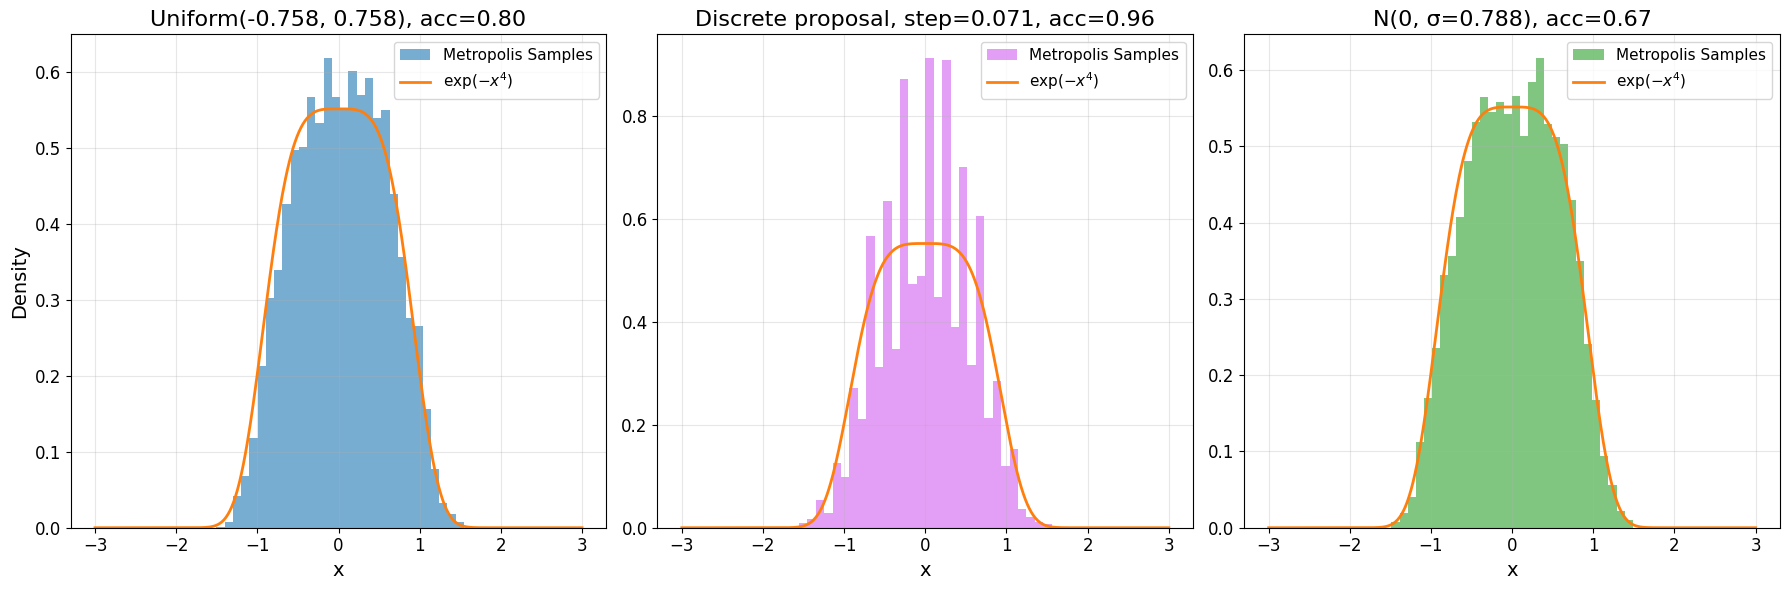

In [377]:
N = 10000

metropolis_results = {}
# True density based on samples
x_vals = np.linspace(-3, 3, 500)
true_density = target_fn(x_vals, Z)

# Metropolis samples
samples_uniform, acc_uniform = universal_metropolis_sampler(dist="uniform", num_samples=N, z=Z,
                                                            initial_x=INITIAL_X, step_size=final_table.loc["Uniform"]["Step Size"])
samples_discrete, acc_discrete = universal_metropolis_sampler(dist="discrete", num_samples=N, z=Z,
                                                  initial_x=INITIAL_X, step_size=final_table.loc["Discrete"]["Step Size"])
samples_normal, acc_normal = universal_metropolis_sampler(dist="normal", num_samples=N, z=Z,
                                                          initial_x=INITIAL_X, sigma=final_table.loc["Normal"]["Step Size"])

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# ---------- First plot ----------
ax[0].hist(samples_uniform,
           bins=B1,
           density=True,
           alpha=0.6,
           color=UNIFORM_COLOR,
           label="Metropolis Samples")

ax[0].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label=r'$\exp(-x^4)$')

ax[0].set_title(
    f"Uniform(-{final_table.loc["Uniform"]["Step Size"]}, {final_table.loc["Uniform"]}), Acceptance Rate={final_table.loc["Uniform"]["Acceptance Rate"]:.2f}",
    fontsize=TITLE_SIZE
)

ax[0].set_xlabel("x", fontsize=LABEL_SIZE)
ax[0].set_ylabel("Density", fontsize=LABEL_SIZE)
ax[0].tick_params(axis='both', labelsize=TICK_SIZE)
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=LEGEND_SIZE)

# ---------- Second plot ----------
ax[1].hist(samples_discrete,
           bins=B2,
           density=True,
           alpha=0.6,
           color=DISCRETE_COLOR,
           label="Metropolis Samples")

ax[1].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label=r'$\exp(-x^4)$')

ax[1].set_title(
    f"discrete (Step={final_table.loc["Discrete"]["Step Size"]:.2f}), Acceptance Rate={final_table.loc["Discrete"]["Acceptance Rate"]:.2f}",
    fontsize=TITLE_SIZE
)

ax[1].set_xlabel("x", fontsize=LABEL_SIZE)
ax[1].tick_params(axis='both', labelsize=TICK_SIZE)
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=LEGEND_SIZE)

# ---------- Third plot ----------
ax[2].hist(samples_normal,
           bins=B3,
           density=True,
           alpha=0.6,
           color=NORMAL_COLOR,
           label="Metropolis Samples")

ax[2].plot(x_vals,
           true_density,
           linewidth=2,
           color=TRUE_DENSITY_COLOR,
           label=r'$\exp(-x^4)$')

ax[2].set_title(
    f"Normal(0, {final_table.loc["Normal"]["Step Size"]}), Acceptance Rate={final_table.loc["Normal"]["Acceptance Rate"]:.2f}",
    fontsize=TITLE_SIZE
)

ax[2].set_xlabel("x", fontsize=LABEL_SIZE)

ax[2].tick_params(axis='both', labelsize=TICK_SIZE)

ax[2].grid(True, alpha=0.3)

ax[2].legend(fontsize=LEGEND_SIZE)
for idx, proposal in enumerate(["Uniform", "Discrete", "Normal"]):
    step = final_table.loc[proposal, "Step Size"]
    acc = final_table.loc[proposal, "Acceptance Rate"]
    if proposal == "Uniform":
        title = f"Uniform(-{step:.3f}, {step:.3f}), acc={acc:.2f}"
    elif proposal == "Discrete":
        title = f"Discrete proposal, step={step:.3f}, acc={acc:.2f}"
    else:
        title = f"N(0, σ={step:.3f}), acc={acc:.2f}"
    ax[idx].set_title(title, fontsize=TITLE_SIZE)
# Better spacing
plt.tight_layout()

# High quality export
plt.savefig(
    "../../Figures/best_proposals_comparison_2e.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

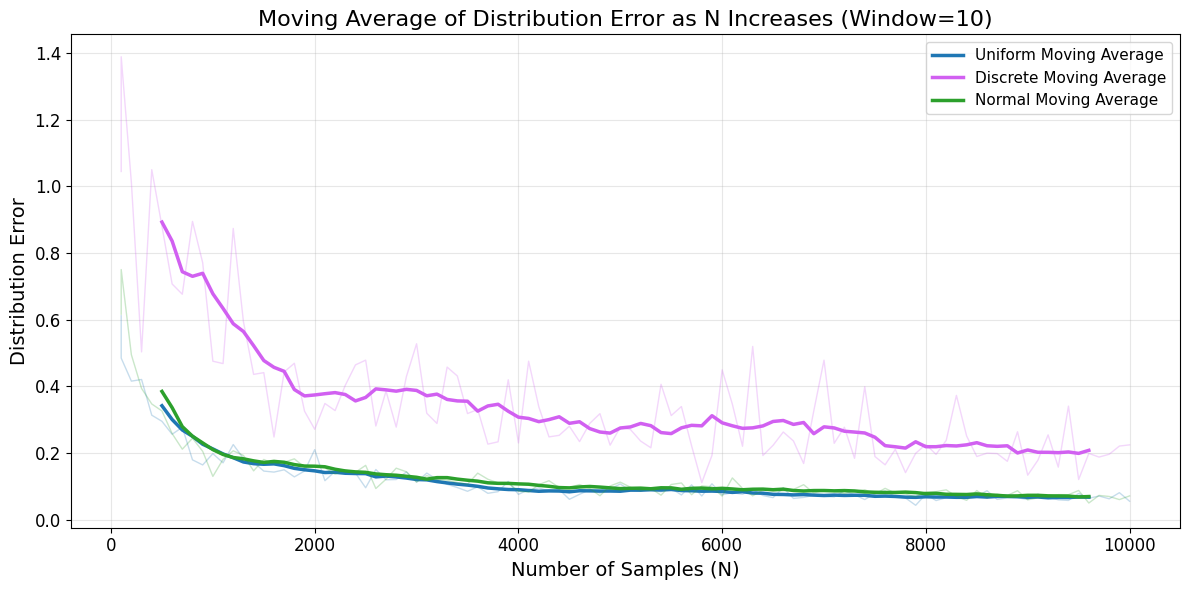

In [381]:
# ============================================================
# Moving Average Plot for Distribution Error
# ============================================================

MOVING_AVG_WINDOW = 10   # try 10 or 20

fig, ax = plt.subplots(figsize=(12, 6))

proposal_styles = {
    "Uniform": {"color": UNIFORM_COLOR, "label": "Uniform"},
    "Discrete": {"color": DISCRETE_COLOR, "label": "Discrete"},
    "Normal": {"color": NORMAL_COLOR, "label": "Normal"},
}

best_uniform_step = final_table.loc["Uniform", "Step Size"]
best_discrete_step = final_table.loc["Discrete", "Step Size"]
best_normal_sigma = final_table.loc["Normal", "Step Size"]

best_convergence_rows = []
for N_current in N_values:
    with contextlib.redirect_stdout(io.StringIO()):
        samples_uniform, acc_uniform = universal_metropolis_sampler(
            dist="uniform",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=best_uniform_step
        )
        samples_discrete, acc_discrete = universal_metropolis_sampler(
            dist="discrete",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            step_size=best_discrete_step
        )
        samples_normal, acc_normal = universal_metropolis_sampler(
            dist="normal",
            num_samples=N_current,
            initial_x=INITIAL_X,
            z=Z,
            sigma=best_normal_sigma
        )

    best_convergence_rows.append({
        "N": N_current,
        "Proposal": "Uniform",
        "Distribution Error": distribution_l1_error(samples_uniform),
        "Acceptance Rate": acc_uniform
    })
    best_convergence_rows.append({
        "N": N_current,
        "Proposal": "Discrete",
        "Distribution Error": distribution_l1_error(samples_discrete),
        "Acceptance Rate": acc_discrete
    })
    best_convergence_rows.append({
        "N": N_current,
        "Proposal": "Normal",
        "Distribution Error": distribution_l1_error(samples_normal),
        "Acceptance Rate": acc_normal
    })

convergence_df = pd.DataFrame(best_convergence_rows)

for proposal_name, style in proposal_styles.items():

    proposal_df = convergence_df[
        convergence_df["Proposal"] == proposal_name
    ].sort_values("N").copy()

    proposal_df["Moving Average"] = (
        proposal_df["Distribution Error"]
        .rolling(window=MOVING_AVG_WINDOW, center=True)
        .mean()
    )

    # Raw line, lighter
    ax.plot(
        proposal_df["N"],
        proposal_df["Distribution Error"],
        linewidth=1,
        alpha=0.25,
        color=style["color"]
    )

    # Moving average line
    ax.plot(
        proposal_df["N"],
        proposal_df["Moving Average"],
        linewidth=2.5,
        color=style["color"],
        label=f"{style['label']} Moving Average"
    )

ax.set_title(
    f"Moving Average of Distribution Error as N Increases "
    f"(Window={MOVING_AVG_WINDOW})",
    fontsize=TITLE_SIZE
)

ax.set_xlabel("Number of Samples (N)", fontsize=LABEL_SIZE)
ax.set_ylabel("Distribution Error", fontsize=LABEL_SIZE)

ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=LEGEND_SIZE)

plt.tight_layout()

plt.savefig(
    "../../Figures/best_convergence_moving_average_2e.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()